# Fine-Tune Cellpose for Segmentation

This notebook provides a workflow for fine-tuning Cellpose models (e.g., CPSAM) using your corrected masks.

## Supported Training Modes

- **`secondary_obj`**: Fine-tune for secondary object segmentation (matches `segment_second_objs_ml`)
- **`cells`**: Fine-tune for cell segmentation (matches `segment_cellpose` with cells=True)
- **`nuclei`**: Fine-tune for nuclei-only segmentation (matches `segment_cellpose` with cells=False)

## Workflow
1. Select training mode and configure channel indices
2. Load training data (images + corrected masks)
3. Apply data augmentation (critical for small datasets)
4. Train/fine-tune the model
5. Evaluate performance
6. Save the trained model
7. Test on new images

## Prerequisites
- Corrected masks saved as `.npy` or `.tif` files (labeled masks where each object has a unique ID)
- Corresponding images (TIFF format, multi-channel)

## Key Feature: Preprocessing Consistency
The preprocessing applied during training now matches the preprocessing used in deployment functions:
- **secondary_obj**: Log scaling + max normalization (matches `segment_second_objs_ml`)
- **cells**: Log scaling + percentile normalization + RGB conversion (matches `prepare_cellpose`)
- **nuclei**: Percentile normalization (matches `segment_cellpose_nuclei_rgb`)

This ensures your fine-tuned models perform optimally when deployed.

## <font color='red'>SET PARAMETERS</font>

### Training Mode
- `TRAINING_MODE`: Preprocessing mode that must match your deployment target
  - `"secondary_obj"`: For segment_second_objs_ml (single channel, log scaling)
  - `"cells"`: For segment_cellpose with cells=True (3-channel RGB)
  - `"nuclei"`: For segment_cellpose with cells=False (DAPI only)

### Training Data Paths
- `IMAGE_DIR`: Directory containing training images (TIFF format)
- `MASK_DIR`: Directory containing corrected masks (NPY format)

### Channel Configuration
- For `secondary_obj` mode: Set `CHANNEL_INDEX` (e.g., CDPK1 channel)
- For `cells`/`nuclei` modes: Set `DAPI_INDEX`, `CYTO_INDEX`, `HELPER_INDEX`

### Model Configuration
- `BASE_MODEL`: Base Cellpose model to fine-tune from ("cpsam", "cyto3", "cyto2", "nuclei")
- `MODEL_NAME`: Name for the fine-tuned model
- `MODEL_SAVE_DIR`: Directory to save the trained model

In [1]:
from pathlib import Path

# =============================================================================
# TRAINING MODE - must match your deployment target
# =============================================================================
# Options:
#   "secondary_obj" - for segment_second_objs_ml (single channel, log scaling)
#   "cells"         - for segment_cellpose with cells=True (3-channel RGB)
#   "nuclei"        - for segment_cellpose with cells=False (DAPI only)
TRAINING_MODE = "secondary_obj"

# =============================================================================
# Training data paths
# =============================================================================
IMAGE_DIR = Path("training_data/images")
MASK_DIR = Path("training_data/masks")

# =============================================================================
# Channel configuration (set based on TRAINING_MODE)
# =============================================================================
# For secondary_obj mode: single channel for secondary object segmentation
CHANNEL_INDEX = 6  # e.g., CDPK1 channel index after alignment

# For cells/nuclei modes: channels matching segment_cellpose
DAPI_INDEX = 0      # Nuclear/DAPI channel
CYTO_INDEX = 1      # Cytoplasmic channel (only needed for cells mode)
HELPER_INDEX = None  # Optional helper channel for CPSAM (can be None)
LOGSCALE = True     # Apply log scaling (recommended)

# =============================================================================
# Model configuration
# =============================================================================
BASE_MODEL = "cpsam"  # Options: "cpsam", "cyto3", "cyto2", "nuclei"
MODEL_NAME = "cpsam_secondary_obj"
MODEL_SAVE_DIR = Path("models")

# Create directories if they don't exist
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
MASK_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Training mode: {TRAINING_MODE}")
if TRAINING_MODE == "secondary_obj":
    print(f"  Channel index: {CHANNEL_INDEX}")
elif TRAINING_MODE == "cells":
    print(f"  DAPI index: {DAPI_INDEX}, Cyto index: {CYTO_INDEX}, Helper index: {HELPER_INDEX}")
elif TRAINING_MODE == "nuclei":
    print(f"  DAPI index: {DAPI_INDEX}")

Training mode: secondary_obj
  Channel index: 6


## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from glob import glob

from lib.shared.cellpose_training import (
    load_training_data,
    augment_training_data,
    prepare_cellpose_training,
    train_cellpose,
    load_trained_model,
    predict_masks,
    evaluate_segmentation,
    visualize_comparison,
    visualize_training_sample,
)

# For preprocessing new images when testing (uses same function as training/deployment)
from lib.shared.segment_cellpose import prepare_cellpose

/lab/solexa_lourido/USERS/AK/miniforge3/envs/brieflow_viso/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]




Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.4 
platform:       	linux 
python version: 	3.11.14 
torch version:  	2.7.0+cu126! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




## <font color='red'>SET PARAMETERS</font>

### Training Hyperparameters
- `N_EPOCHS`: Number of training epochs (500 recommended for small datasets)
- `LEARNING_RATE`: Initial learning rate
- `BATCH_SIZE`: Training batch size
- `TEST_FRACTION`: Fraction of data to hold out for testing

### Augmentation Settings
- `USE_AUGMENTATION`: Enable/disable data augmentation
- `USE_ROTATIONS`: Apply 90/180/270 degree rotations
- `USE_FLIPS`: Apply horizontal/vertical flips
- `USE_INTENSITY_SCALING`: Apply random intensity scaling

In [3]:
# Training hyperparameters
N_EPOCHS = 20
LEARNING_RATE = 1e-5
BATCH_SIZE = 4
TEST_FRACTION = 0.1
WEIGHT_DECAY = 0.1
GPU = True

# Augmentation settings (recommended for small datasets)
USE_AUGMENTATION = True
USE_ROTATIONS = True
USE_FLIPS = True
USE_INTENSITY_SCALING = True

## 1. Load Training Data

Load paired images and masks. Images should be in TIFF format, masks can be NPY or TIFF format (labeled masks where each object has a unique ID).

**Expected naming convention:**
- Images: `tile_001.tif`, `tile_002.tif`, etc.
- Masks: `tile_001_mask.npy` or `tile_001_mask.tif`, etc.

Or you can manually specify the paths below.

In [4]:
# Find all image and mask files
image_files = sorted(IMAGE_DIR.glob("*.tif")) + sorted(IMAGE_DIR.glob("*.tiff"))
mask_files = sorted(MASK_DIR.glob("*.npy")) + sorted(MASK_DIR.glob("*.tif")) + sorted(MASK_DIR.glob("*.tiff"))

print(f"Found {len(image_files)} images and {len(mask_files)} masks")

if len(image_files) == 0:
    print("\n" + "="*60)
    print("No training data found!")
    print("\nPlease add your training data:")
    print(f"  - Images (.tif): {IMAGE_DIR.absolute()}")
    print(f"  - Masks (.npy or .tif):  {MASK_DIR.absolute()}")
    print("="*60)

Found 4 images and 4 masks


In [5]:
# Option 1: Auto-pair files by name (assumes matching names)
# This cell pairs images and masks that share the same base identifier (e.g., A1_200)
import re

def extract_identifier(filename):
    """Extract well + tile identifier (e.g., 'A1_200') from filename."""
    # Match pattern like A1_200, B12_150, etc.
    match = re.search(r'([A-Z]\d+_\d+)', filename)
    return match.group(1) if match else None

def pair_images_masks(image_files, mask_files):
    """Pair images with masks based on identifier matching."""
    paired_images = []
    paired_masks = []
    
    # Build mask dict keyed by identifier
    mask_dict = {}
    for m in mask_files:
        identifier = extract_identifier(m.stem)
        if identifier:
            mask_dict[identifier] = m
    
    for img_path in image_files:
        identifier = extract_identifier(img_path.stem)
        if identifier and identifier in mask_dict:
            paired_images.append(img_path)
            paired_masks.append(mask_dict[identifier])
            print(f"  Paired: {img_path.name} <-> {mask_dict[identifier].name}")
    
    return paired_images, paired_masks

if len(image_files) > 0 and len(mask_files) > 0:
    print("Pairing images and masks...")
    image_paths, mask_paths = pair_images_masks(image_files, mask_files)
    print(f"\nSuccessfully paired {len(image_paths)} image-mask pairs")


Pairing images and masks...
  Paired: aligned_image_A1_200.tiff <-> corrected_second_obj_masks_A1_200.tif
  Paired: aligned_image_A1_250.tiff <-> corrected_second_obj_masks_A1_250.tif
  Paired: aligned_image_A2_200.tiff <-> corrected_second_obj_masks_A2_200.tif
  Paired: aligned_image_A2_250.tiff <-> corrected_second_obj_masks_A2_250.tif

Successfully paired 4 image-mask pairs


In [6]:
# Option 2: Manually specify paths if auto-pairing doesn't work
# Uncomment and modify this cell if needed

# image_paths = [
#     Path("training_data/images/tile_001.tif"),
#     Path("training_data/images/tile_002.tif"),
# ]
# mask_paths = [
#     Path("training_data/masks/tile_001_mask.npy"),
#     Path("training_data/masks/tile_002_mask.npy"),
# ]

In [7]:
# Load the training data with mode-specific preprocessing
if len(image_paths) > 0:
    if TRAINING_MODE == "secondary_obj":
        images, masks = load_training_data(
            image_paths,
            mask_paths,
            mode="secondary_obj",
            channel_index=CHANNEL_INDEX,
            logscale=LOGSCALE,
        )
    elif TRAINING_MODE == "cells":
        images, masks = load_training_data(
            image_paths,
            mask_paths,
            mode="cells",
            dapi_index=DAPI_INDEX,
            cyto_index=CYTO_INDEX,
            helper_index=HELPER_INDEX,
            logscale=LOGSCALE,
        )
    elif TRAINING_MODE == "nuclei":
        images, masks = load_training_data(
            image_paths,
            mask_paths,
            mode="nuclei",
            dapi_index=DAPI_INDEX,
            logscale=LOGSCALE,
        )
    else:
        raise ValueError(f"Unknown TRAINING_MODE: {TRAINING_MODE}")
    
    print(f"\nImage shape: {images[0].shape}")
    print(f"Image dtype: {images[0].dtype}")
    print(f"Mask shape: {masks[0].shape}")
    print(f"Number of objects in first mask: {masks[0].max()}")

Loaded 4 image-mask pairs (mode=secondary_obj)

Image shape: (2400, 2400)
Image dtype: uint8
Mask shape: (2400, 2400)
Number of objects in first mask: 149


## 2. Visualize Training Data

Inspect a few training samples to verify masks are correctly loaded.

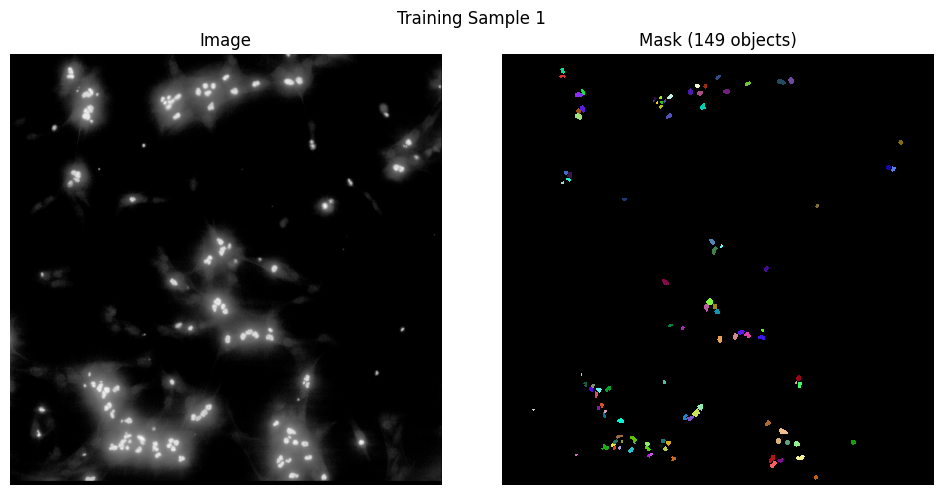

In [8]:
# Visualize first few training samples
n_samples_to_show = min(1, len(images))

for i in range(n_samples_to_show):
    fig = visualize_training_sample(
        images[i], 
        masks[i], 
        title=f"Training Sample {i+1}"
    )
    plt.show()

## 3. Data Augmentation

For small datasets (5-20 images), augmentation is critical for successful training.

This will expand your dataset by applying:
- 90°, 180°, 270° rotations (4x multiplier)
- Horizontal and vertical flips (2x multiplier)
- Intensity scaling (optional, adds more variation)

**Expected expansion**: 10 images → ~80-160 training samples

In [9]:
if USE_AUGMENTATION:
    print(f"Original dataset: {len(images)} samples")
    
    aug_images, aug_masks = augment_training_data(
        images,
        masks,
        rotations=USE_ROTATIONS,
        flips=USE_FLIPS,
        intensity_scaling=USE_INTENSITY_SCALING,
    )
    
    print(f"Augmented dataset: {len(aug_images)} samples")
else:
    aug_images = images
    aug_masks = masks
    print(f"Augmentation disabled. Using {len(aug_images)} original samples.")

Original dataset: 4 samples
Augmentation: 4 original → 64 samples (16.0x expansion)
Augmented dataset: 64 samples


Sample augmented images:


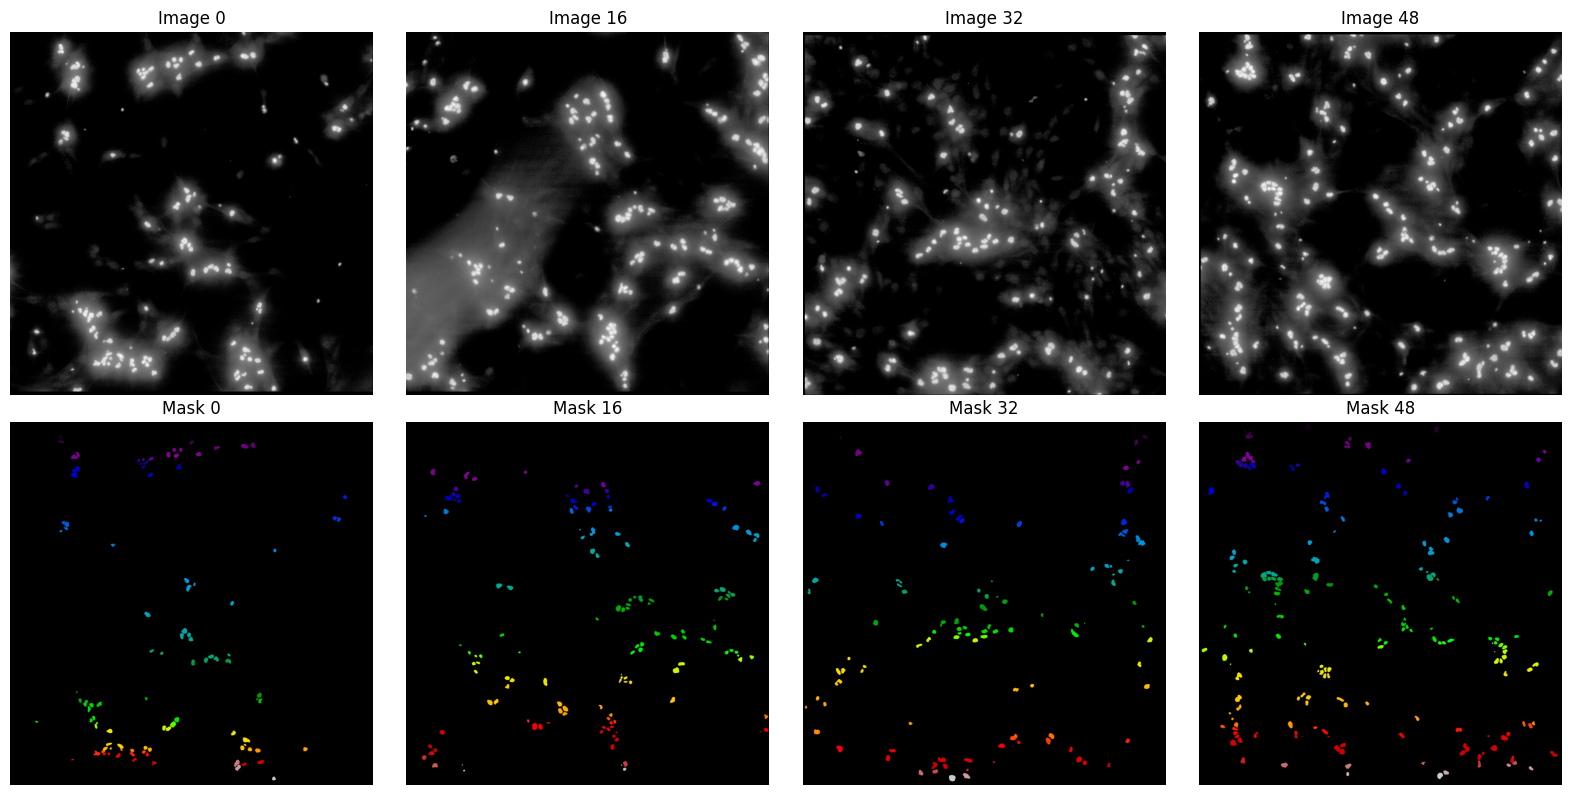

In [10]:
# Visualize some augmented samples
if USE_AUGMENTATION:
    print("Sample augmented images:")
    indices = [0, len(aug_images)//4, len(aug_images)//2, 3*len(aug_images)//4]
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i, idx in enumerate(indices):
        axes[0, i].imshow(aug_images[idx], cmap='gray')
        axes[0, i].set_title(f'Image {idx}')
        axes[0, i].axis('off')
        
        axes[1, i].imshow(aug_masks[idx], cmap='nipy_spectral')
        axes[1, i].set_title(f'Mask {idx}')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

## 4. Prepare Training/Test Split

In [11]:
# Split into training and test sets
train_images, train_masks, test_images, test_masks = prepare_cellpose_training(
    aug_images,
    aug_masks,
    test_fraction=TEST_FRACTION,
    seed=42
)

print(f"\nTraining set: {len(train_images)} samples")
print(f"Test set: {len(test_images)} samples")

Split: 58 training, 6 test samples

Training set: 58 samples
Test set: 6 samples


## 5. Train the Model

This cell will fine-tune the Cellpose model. Training progress will be displayed.

**Note**: Training can take 30-60 minutes depending on dataset size and GPU availability.

In [12]:
# Train the model
print(f"Starting training...")
print(f"  Base model: {BASE_MODEL}")
print(f"  Epochs: {N_EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  GPU: {GPU}")
print()

model = train_cellpose(
    train_images=train_images,
    train_masks=train_masks,
    test_images=test_images,
    test_masks=test_masks,
    base_model=BASE_MODEL,
    n_epochs=N_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    batch_size=BATCH_SIZE,
    save_path=MODEL_SAVE_DIR,
    model_name=MODEL_NAME,
    gpu=GPU,
)

Starting training...
  Base model: cpsam
  Epochs: 20
  Learning rate: 1e-05
  Batch size: 4
  GPU: True

2026-02-02 12:04:08,025 [INFO] WRITING LOG OUTPUT TO /home/acepedadiaz/.cellpose/run.log
2026-02-02 12:04:08,026 [INFO] 
cellpose version: 	4.0.4 
platform:       	linux 
python version: 	3.11.14 
torch version:  	2.7.0+cu126
Initializing model from base: cpsam
Training parameters: epochs=20, lr=1e-05, batch=4
2026-02-02 12:04:08,327 [INFO] ** TORCH CUDA version installed and working. **
2026-02-02 12:04:08,328 [INFO] >>>> using GPU (CUDA)
2026-02-02 12:04:10,596 [INFO] >>>> loading model /home/acepedadiaz/.cellpose/models/cpsam
Starting training with 58 samples...
2026-02-02 12:04:11,245 [INFO] computing flows for labels


100%|██████████| 58/58 [00:14<00:00,  3.88it/s]

2026-02-02 12:04:26,708 [INFO] computing flows for labels



100%|██████████| 6/6 [00:01<00:00,  3.75it/s]

2026-02-02 12:04:28,367 [INFO] >>> computing diameters



100%|██████████| 6/6 [00:00<00:00, 57.66it/s]

2026-02-02 12:04:29,471 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-02-02 12:04:37,115 [INFO] >>> n_epochs=20, n_train=58, n_test=6
2026-02-02 12:04:37,116 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.10000
2026-02-02 12:04:37,172 [INFO] >>> saving model to models/models/cpsam_secondary_obj
2026-02-02 12:04:51,042 [INFO] 0, train_loss=0.2985, test_loss=0.1118, LR=0.000000, time 13.92s
2026-02-02 12:05:54,323 [INFO] 5, train_loss=0.1565, test_loss=0.0429, LR=0.000006, time 77.20s
2026-02-02 12:06:58,096 [INFO] 10, train_loss=0.1066, test_loss=0.0242, LR=0.000010, time 140.98s
2026-02-02 12:08:50,493 [INFO] saving network parameters to models/models/cpsam_secondary_obj
Training complete. Model saved to: models/models/cpsam_secondary_obj
2026-02-02 12:08:58,954 [INFO] ** TORCH CUDA version installed and working. **
2026-02-02 12:08:58,956 [INFO] >>>> using GPU (CUDA)
2026-02-02 12:09:00,950 [INFO] >>>> loading model models/models/cpsam_secondary_obj


## 6. Evaluate Performance

Compare the fine-tuned model against the base model on the test set.

In [13]:
# # Evaluate the fine-tuned model
# print("Evaluating fine-tuned model on test set...")
# finetuned_metrics = evaluate_segmentation(
#     model,
#     test_images,
#     test_masks,
# )

# print(f"\nFine-tuned Model Performance:")
# print(f"  Mean IoU:       {finetuned_metrics['mean_iou']:.3f}")
# print(f"  Mean Precision: {finetuned_metrics['mean_precision']:.3f}")
# print(f"  Mean Recall:    {finetuned_metrics['mean_recall']:.3f}")
# print(f"  Mean F1:        {finetuned_metrics['mean_f1']:.3f}")

In [14]:
# # Compare with base model (optional)
# from cellpose import models as cp_models

# print("Evaluating base model for comparison...")
# base_model = cp_models.CellposeModel(gpu=GPU, model_type=BASE_MODEL)

# base_metrics = evaluate_segmentation(
#     base_model,
#     test_images,
#     test_masks,
# )

# print(f"\nBase Model ({BASE_MODEL}) Performance:")
# print(f"  Mean IoU:       {base_metrics['mean_iou']:.3f}")
# print(f"  Mean Precision: {base_metrics['mean_precision']:.3f}")
# print(f"  Mean Recall:    {base_metrics['mean_recall']:.3f}")
# print(f"  Mean F1:        {base_metrics['mean_f1']:.3f}")

# print(f"\n{'='*50}")
# print("Improvement Summary:")
# print(f"  IoU:       {finetuned_metrics['mean_iou'] - base_metrics['mean_iou']:+.3f}")
# print(f"  Precision: {finetuned_metrics['mean_precision'] - base_metrics['mean_precision']:+.3f}")
# print(f"  Recall:    {finetuned_metrics['mean_recall'] - base_metrics['mean_recall']:+.3f}")
# print(f"  F1:        {finetuned_metrics['mean_f1'] - base_metrics['mean_f1']:+.3f}")

Evaluating base model for comparison...
2026-02-02 12:09:07,932 [WARNING] model_type argument is not used in v4.0.1+. Ignoring this argument...
2026-02-02 12:09:07,933 [INFO] ** TORCH CUDA version installed and working. **
2026-02-02 12:09:07,933 [INFO] >>>> using GPU (CUDA)
2026-02-02 12:09:09,923 [INFO] >>>> loading model /home/acepedadiaz/.cellpose/models/cpsam
2026-02-02 12:09:10,514 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-02-02 12:09:54,011 [INFO] 100%|##########| 6/6 [00:43<00:00,  7.25s/it]


KeyboardInterrupt: 

## 7. Visualize Predictions

Compare predictions from the fine-tuned model against ground truth.

2026-02-02 12:15:35,135 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-02-02 12:15:35,138 [INFO] 0%|          | 0/6 [00:00<?, ?it/s]
2026-02-02 12:16:09,614 [INFO] No cell pixels found.
2026-02-02 12:16:17,029 [INFO] 100%|##########| 6/6 [00:41<00:00,  6.98s/it]


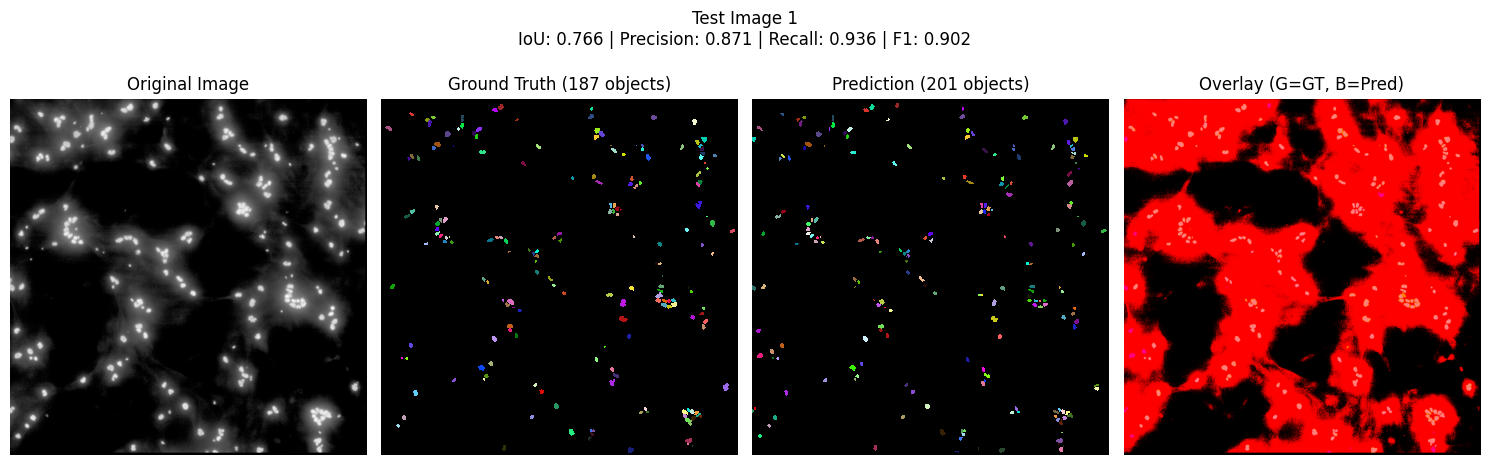

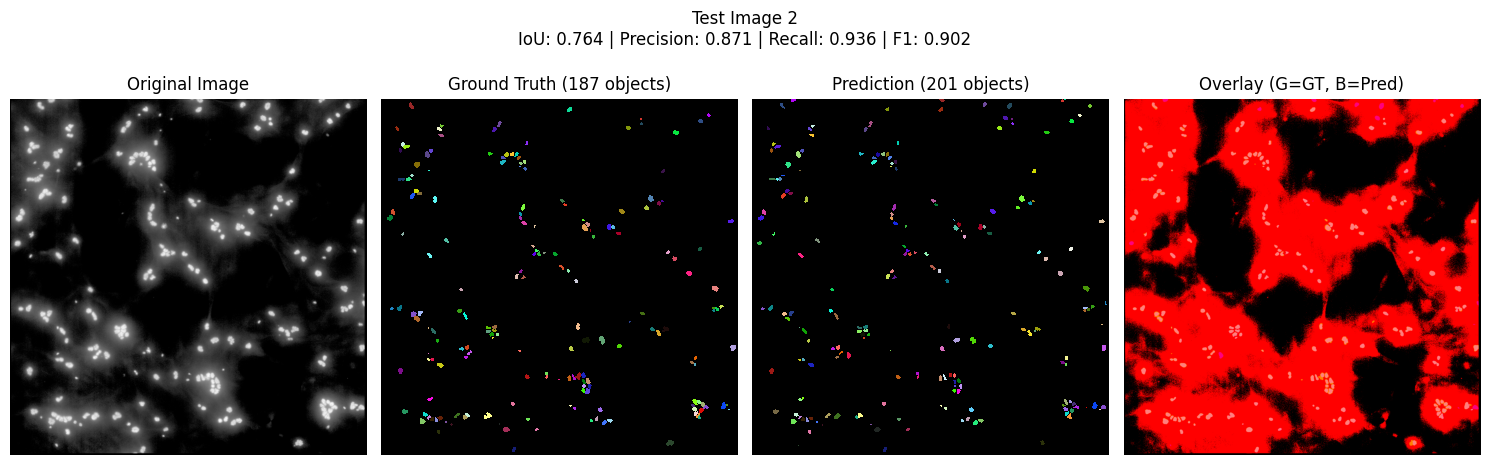

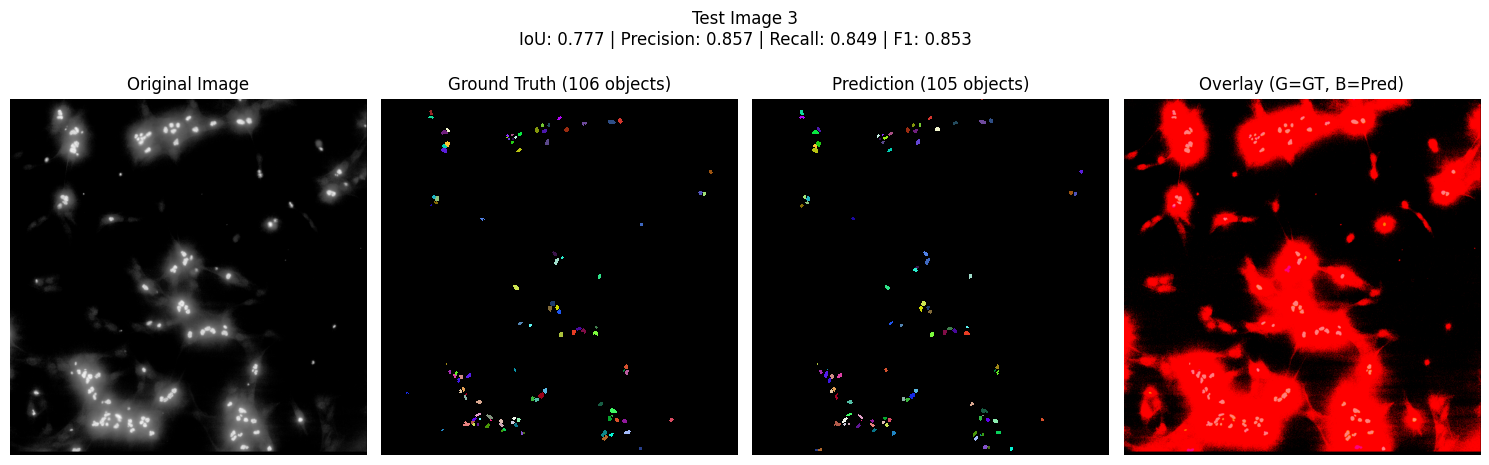

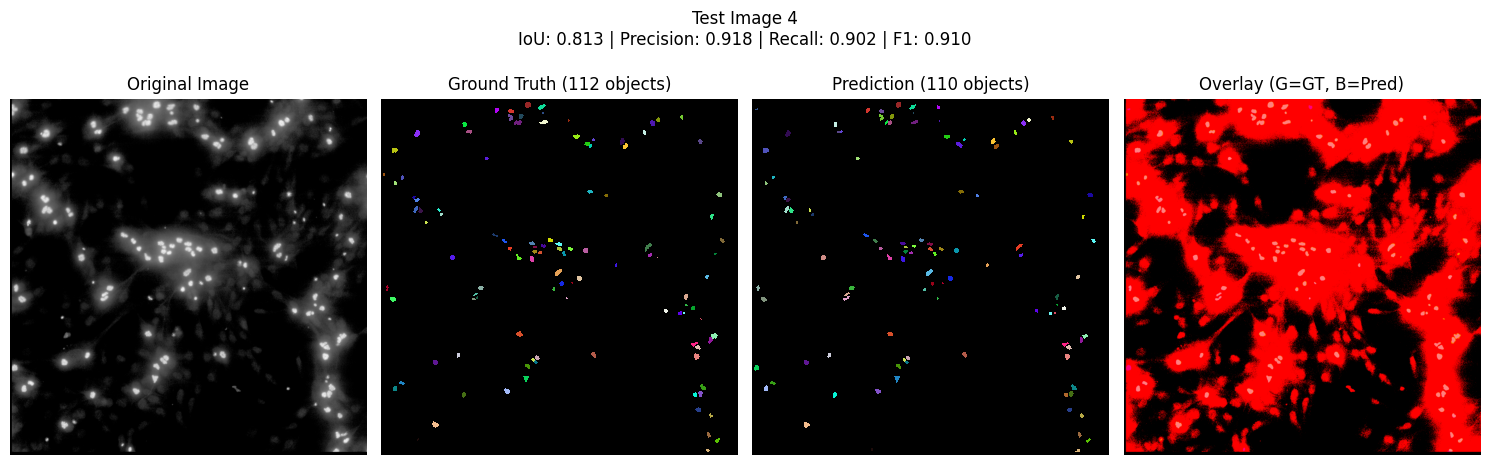

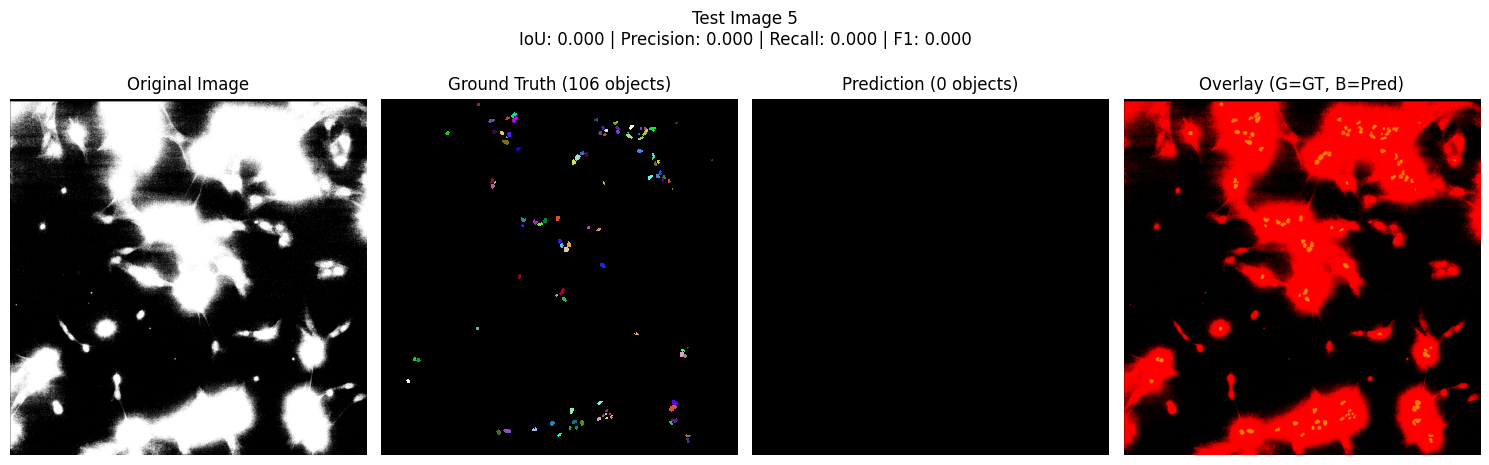

In [15]:
# Get predictions on test set
pred_masks = predict_masks(model, test_images)

# Visualize comparisons
n_to_show = min(5, len(test_images))

for i in range(n_to_show):
    fig = visualize_comparison(
        test_images[i],
        pred_masks[i],
        test_masks[i],
        title=f"Test Image {i+1}"
    )
    plt.show()

## 8. Save Model Information

Save training configuration for reproducibility.

In [16]:
import json
from datetime import datetime

# Save training configuration
config = {
    "model_name": MODEL_NAME,
    "base_model": BASE_MODEL,
    "training_date": datetime.now().isoformat(),
    "n_epochs": N_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "n_original_samples": len(images),
    "n_augmented_samples": len(aug_images),
    "n_train_samples": len(train_images),
    "n_test_samples": len(test_images),
    "augmentation": {
        "enabled": USE_AUGMENTATION,
        "rotations": USE_ROTATIONS,
        "flips": USE_FLIPS,
        "intensity_scaling": USE_INTENSITY_SCALING,
    },
    # "metrics": {
    #     "finetuned": {
    #         "mean_iou": finetuned_metrics["mean_iou"],
    #         "mean_precision": finetuned_metrics["mean_precision"],
    #         "mean_recall": finetuned_metrics["mean_recall"],
    #         "mean_f1": finetuned_metrics["mean_f1"],
    #     }
    # }
}

config_path = MODEL_SAVE_DIR / f"{MODEL_NAME}_config.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"Training configuration saved to: {config_path}")
print(f"\nModel saved to: {MODEL_SAVE_DIR / MODEL_NAME}")

Training configuration saved to: models/cpsam_secondary_obj_config.json

Model saved to: models/cpsam_secondary_obj


## 9. Test on New Image

Load and test the fine-tuned model on a completely new image.

In [ ]:
# Load the fine-tuned model (demonstrates how to load for future use)
model_path = MODEL_SAVE_DIR / MODEL_NAME

# Find the actual model file (Cellpose adds epoch number)
model_files = list(MODEL_SAVE_DIR.glob(f"{MODEL_NAME}*"))
if model_files:
    latest_model = max(model_files, key=lambda x: x.stat().st_mtime)
    print(f"Loading model from: {latest_model}")
    loaded_model = load_trained_model(latest_model, gpu=GPU)
else:
    print("Model file not found. Using the model from training.")
    loaded_model = model

In [ ]:
# Set path to a new test image (not in training set)
# Modify this path to point to your test image

NEW_IMAGE_PATH = "/lab/ops_analysis_hdd/lourido/viso-analysis/analysis/aligned_image_A3_200.tiff"  # Set to your test image path, e.g., "path/to/test_image.tif"

if NEW_IMAGE_PATH:
    # Load the new image
    new_image_raw = imread(str(NEW_IMAGE_PATH))
    
    # Apply the same preprocessing as training using prepare_cellpose
    # This ensures consistency with both training and deployment functions
    if TRAINING_MODE == "secondary_obj":
        # Use prepare_cellpose with target channel as cyto, extract green channel
        rgb = prepare_cellpose(
            new_image_raw,
            dapi_index=CHANNEL_INDEX,  # Dummy
            cyto_index=CHANNEL_INDEX,  # Target channel
            helper_index=None,
            logscale=LOGSCALE,
        )
        new_image = rgb[1]  # Extract green (log scaled + normalized)
        
    elif TRAINING_MODE == "cells":
        # Use prepare_cellpose for 3-channel RGB
        new_image = prepare_cellpose(
            new_image_raw,
            dapi_index=DAPI_INDEX,
            cyto_index=CYTO_INDEX,
            helper_index=HELPER_INDEX,
            logscale=LOGSCALE,
        )
        
    elif TRAINING_MODE == "nuclei":
        # Use prepare_cellpose, extract blue channel (DAPI)
        rgb = prepare_cellpose(
            new_image_raw,
            dapi_index=DAPI_INDEX,
            cyto_index=DAPI_INDEX,  # Dummy
            helper_index=None,
            logscale=False,  # DAPI uses percentile norm, not log scale
        )
        new_image = rgb[2]  # Extract blue (DAPI)
    
    # Run inference
    print("Running inference on new image...")
    new_masks = predict_masks(loaded_model, [new_image])
    
    # Visualize (handle 2D and 3D cases)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    display_img = new_image if new_image.ndim == 2 else new_image[1]  # Use green channel for RGB
    axes[0].imshow(display_img, cmap='gray')
    axes[0].set_title('Input Image (preprocessed)')
    axes[0].axis('off')
    
    axes[1].imshow(new_masks[0], cmap='nipy_spectral')
    axes[1].set_title(f'Segmentation ({new_masks[0].max()} objects)')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Set NEW_IMAGE_PATH to test on a new image.")

## 10. Integration with Analysis Notebooks

### For Secondary Object Segmentation

To use the fine-tuned model in your phenotype analysis pipeline, update the `SECOND_OBJ_CELLPOSE_MODEL` parameter in `3.configure_phenotype_params_second_obj.ipynb`:

```python
# Instead of:
SECOND_OBJ_CELLPOSE_MODEL = "cpsam"

# Use:
SECOND_OBJ_CELLPOSE_MODEL = "models/cpsam_secondary_obj"  # Path to your fine-tuned model
```

The `segment_second_objs_ml()` function now applies the same log scaling preprocessing that was used during training, ensuring consistent results.

### For Cell/Nuclei Segmentation

If you trained with `TRAINING_MODE="cells"` or `"nuclei"`, update the `CELLPOSE_MODEL` parameter in your preprocessing notebook:

```python
# For cell segmentation:
CELLPOSE_MODEL = "models/cpsam_cells"  # Path to your fine-tuned cell model

# For nuclei-only segmentation:
CELLPOSE_MODEL = "models/cpsam_nuclei"  # Path to your fine-tuned nuclei model
```

**Important**: The preprocessing (log scaling, percentile normalization) applied during training now matches the preprocessing in the deployment functions (`segment_second_objs_ml`, `segment_cellpose`), ensuring the fine-tuned model performs optimally.

In [ ]:
# Print the model path for easy copy-paste
print("\nTo use this model in your phenotype notebook:")
print(f'SECOND_OBJ_CELLPOSE_MODEL = "{MODEL_SAVE_DIR / MODEL_NAME}"')